# Garden-path underestimation vs. model size (Pythia 70M-6.9B)

In [1]:
import os, gc, re, math
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import torch
from tqdm.auto import tqdm
import urllib.request
import gdown
from transformers import AutoTokenizer, GPTNeoXForCausalLM


#setting up the folders to store the data and results
data_dir, res_dir = "data", "results"
for d in (f"{data_dir}/sap", f"{data_dir}/naturalstories", res_dir):
    os.makedirs(d, exist_ok=True)

# paths to files
spr_gp_path = f"{data_dir}/sap/ClassicGardenPathSet.csv"
spr_fill_path = f"{data_dir}/sap/Fillers.csv"
freq_csv_path = f"{data_dir}/freqs_coca.csv"
ns_tok_path = f"{data_dir}/naturalstories/all_stories.tok"
ns_rt_path = f"{data_dir}/naturalstories/processed_RTs.tsv"

# models to run
MODELS = [
    ("pythia-70m-deduped", 70e6),
    ("pythia-160m-deduped", 160e6),
    ("pythia-410m-deduped", 410e6),
    ("pythia-1.4b-deduped", 1.4e9),
    ("pythia-2.8b-deduped", 2.8e9),
    ("pythia-6.9b-deduped", 6.9e9)
]
#max filler readint imes to be kept (this is used to speed ip regression)
MAX_FILLER_ROWS = 250_000

#a word types must appear at least this many times in natural text for the excess-confidence test

# the number of bootstrap iterations used to generate 95% confidence intervals
N_BOOT = 2000

# number of random shuffles to be done for the permutation p-value test
N_PERM = 5000

#### Downloading required files and setting up frequency data.

In [3]:

# downloading natural stories and frquency data
urllib.request.urlretrieve("https://raw.githubusercontent.com/languageMIT/naturalstories/master/naturalstories_RTS/all_stories.tok", ns_tok_path)
urllib.request.urlretrieve("https://raw.githubusercontent.com/languageMIT/naturalstories/master/naturalstories_RTS/processed_RTs.tsv", ns_rt_path)


urllib.request.urlretrieve("https://raw.githubusercontent.com/caplabnyu/sapbenchmark/main/Surprisals/analysis/freqs_coca.csv", freq_csv_path)

#downloading the SAP Benchmark data (ClassicGardenPathSet.csv and Fillers.csv) from google drive
# gdown.download_folder("https://drive.google.com/drive/folders/1g-oyH-XuB2oolo1d8KZfuFtiimuNyhjc", output=f"{data_dir}/sap", quiet=False)

#removeing punctuation and lowercasing the  word for matching
def clean_word(w):

    return re.sub(r"[.,!?:;]", "", str(w).lower())

# loading COCA frequencies and mapping them to a log scale
def load_freq(path):

    f = pd.read_csv(path)
    f = f[f["count"] > 0].copy()

    f["w"] = f["word"].map(clean_word)
    return np.log(f.groupby("w")["count"].sum())

logfreq = load_freq(freq_csv_path)
ns_tok = pd.read_csv(ns_tok_path, sep="\t")

#extracting unique sentences
def unique_sentences(path):

    s = pd.read_csv(path, usecols=["Sentence"])["Sentence"].astype(str).str.replace("%2C", ",", regex=False).str.strip().unique()
    return list(s)

gp_sents = unique_sentences(spr_gp_path)

fill_sents = unique_sentences(spr_fill_path)
print(f"Loaded {len(gp_sents)} GP sentences and {len(fill_sents)} filler sentences.")

Loaded 145 GP sentences and 40 filler sentences.


#### Running inference on Pythia models to extract word-level bits.

In [ ]:
@torch.no_grad()
# dunction to calculate surprisal of each word
def word_surprisals(model, tok, words):


    bos = tok.convert_tokens_to_ids("<|endoftext|>")
    ids, owner = [bos], [-1]

    # tokenizing
    for i, w in enumerate(words):
        t = tok(w if i == 0 else " " + w, add_special_tokens=False)["input_ids"]


        ids += t
        owner += [i] * len(t)

    dev = next(model.parameters()).device
    x = torch.tensor([ids], device=dev)

    # getting log probabilities from model

    lp = torch.log_softmax(model(x).logits[0].float(), dim=-1)
    s = (-lp[:-1].gather(1, x[0, 1:, None])[:, 0] / math.log(2)).cpu().numpy()

    # summing up surprisal of subwords

    out = np.zeros(len(words))

    for k, o in enumerate(owner[1:]):
        out[o] += s[k]
    return out

def extract_all(model, tok):

    rows = []
    for kind, sents in (("gp", gp_sents), ("filler", fill_sents)):

        for s in tqdm(sents, desc=kind):

            words = s.split(" ")
            for i, (w, x) in enumerate(zip(words, word_surprisals(model, tok, words))):
                rows.append((kind, s, i + 1, w, x))

    for it, g in tqdm(list(ns_tok.groupby("item")), desc="naturalstories"):

        g = g.sort_values("zone")
        # zipping together the position z, the word w and the llm suprisal score
        for z, w, x in zip(g.zone, g.word.astype(str), word_surprisals(model, tok, g.word.astype(str).tolist())):
            rows.append(("ns", str(it), int(z), w, x))

    return pd.DataFrame(rows, columns=["kind", "key", "pos", "word", "surprisal"])



for name, _ in MODELS:
    out_path = f"{res_dir}/surp_{name}_fp16.csv"
    if os.path.exists(out_path):
        continue

    tok = AutoTokenizer.from_pretrained(f"EleutherAI/{name}")

    # loading in fp16
    model = GPTNeoXForCausalLM.from_pretrained(f"EleutherAI/{name}",torch_dtype=torch.float16, device_map="auto",low_cpu_mem_usage=True).eval()


    df = extract_all(model, tok)
    df.to_csv(out_path, index=False)


    del model, tok
    gc.collect()
    torch.cuda.empty_cache()



#### Calculating garden-path underestimation, natural stories fit and excess confidence.

In [5]:
#loading human reading time data
def load_spr(path, need_gp):

    cols = ["Sentence", "EachWord", "WordPosition", "RT", "MD5", "item"]

    if need_gp:
        cols += ["ROI", "CONSTRUCTION", "AMBIG"]
    d = pd.read_csv(path, usecols=cols)

    # filtering out times, filtering out negative times and if time is more than 3000 milliseconds
    d = d[(d.RT < 3000) & (d.RT > 0)].copy()

    for c in ("Sentence", "EachWord"):
        d[c] = d[c].astype(str).str.replace("%2C", ",", regex=False).str.strip()

    return d

spr_gp = load_spr(spr_gp_path, True)
spr_fill = load_spr(spr_fill_path, False)
ns_rt = pd.read_csv(ns_rt_path, sep="\t", usecols=["WorkerId", "item", "zone", "RT", "correct"])

#loading suprisal file for the mdoels
def surprisal_path(name):

    for prec in ("fp16", "int8"):
        p = f"{res_dir}/surp_{name}_{prec}.csv"

        if os.path.exists(p):
            return p, prec

    return None, None

# adding features
def word_table(w, nlags):

    w = w.sort_values(["key", "pos"]).copy()

    w["cw"] = w.word.map(clean_word)
    w["logfreq"] = w.cw.map(logfreq)
    w["length"] = w.word.str.len()

    g = w.groupby("key")

    #adding suprisal of previous words into spillover words
    for f in ("surprisal", "logfreq", "length"):
        for k in range(1, nlags + 1):
            w[f"{f}_p{k}"] = g[f].shift(k)

    # removing the last word
    w["is_last"] = w.pos == g.pos.transform("max")

    return w

# calculating the actual human reading time difference between ambiguous and unambiguous sentences
human_eff = spr_gp.groupby(["CONSTRUCTION", "item", "AMBIG", "ROI"]).RT.mean().unstack("AMBIG")
human_eff["human"] = human_eff["Amb"] - human_eff["Unamb"]
human_eff = human_eff["human"].reset_index()

roi_map = spr_gp[["CONSTRUCTION", "item", "AMBIG", "Sentence", "ROI", "WordPosition"]].drop_duplicates()

#caculating the underestimation gap
def gp_model_effects(name):
    path, prec = surprisal_path(name)
    if not path: return None

    S = pd.read_csv(path)
    Wf = word_table(S[S.kind == "filler"], 2)
    Wg = word_table(S[S.kind == "gp"], 2)

    F = spr_fill.merge(Wf, left_on=["Sentence", "WordPosition"], right_on=["key", "pos"], how="left")
    F = F[~F.is_last.fillna(True)].dropna(subset=["surprisal", "surprisal_p1", "surprisal_p2", "logfreq", "logfreq_p1", "logfreq_p2", "length", "length_p1", "length_p2"])

    # normalizing the data
    st = {b: (F[b].mean(), F[b].std()) for b in ("surprisal", "logfreq", "length", "WordPosition")}
    def z(d, col, base):
        return (d[col] - st[base][0]) / st[base][1]

    for i, sfx in enumerate(("", "_p1", "_p2")):
        F[f"s{i}"] = z(F, f"surprisal{sfx}", "surprisal")
        F[f"f{i}"] = z(F, f"logfreq{sfx}", "logfreq")
        F[f"l{i}"] = z(F, f"length{sfx}", "length")
    F["pos"] = z(F, "WordPosition", "WordPosition")

    if len(F) > MAX_FILLER_ROWS:
        keep = np.random.default_rng(0).choice(F.MD5.unique(), int(F.MD5.nunique() * MAX_FILLER_ROWS / len(F)), replace=False)
        F = F[F.MD5.isin(keep)]

    # training  a mixed-effects regression on filler items,  conversion from 'bits' to 'ms'
    res = smf.mixedlm("RT ~ s0 + s1 + s2 + pos + f0*l0 + f1*l1 + f2*l2", F, groups=F["MD5"]).fit(reml=False)
    beta = res.fe_params[["s0", "s1", "s2"]].values

    # applying conversion rate to the garden-path items
    Wg["comp"] = sum(b * (Wg[c] - st["surprisal"][0]) / st["surprisal"][1] for b, c in zip(beta, ("surprisal", "surprisal_p1", "surprisal_p2")))

    M = roi_map.merge(Wg[["key", "pos", "comp", "surprisal"]], left_on=["Sentence", "WordPosition"], right_on=["key", "pos"], how="left")
    M = M[M.ROI.isin([0, 1, 2])].dropna(subset=["comp"])
    P = M.pivot_table(index=["CONSTRUCTION", "item", "ROI"], columns="AMBIG", values=["comp", "surprisal"]).dropna()


    eff = pd.DataFrame({
        "pred_surprisal_ms": P[("comp", "Amb")] - P[("comp", "Unamb")],
        "dbits": P[("surprisal", "Amb")] - P[("surprisal", "Unamb")]
    }).reset_index()

    eff = eff.merge(human_eff, on=["CONSTRUCTION", "item", "ROI"])
    eff["ROI"] = eff["ROI"].astype(str)


    g = eff.groupby(["CONSTRUCTION", "item"])
    win = g[["pred_surprisal_ms", "dbits", "human"]].sum().reset_index()
    win = win[(g.ROI.count() == 3).values]
    win["ROI"] = "0-2"

    eff = pd.concat([eff, win], ignore_index=True)
    eff["model"] = name
    eff["prec"] = prec
    return eff

all_effects = pd.concat([gp_model_effects(n) for n, _ in MODELS if surprisal_path(n)[0]], ignore_index=True)
all_effects.to_csv(f"{res_dir}/gp_item_effects_all_models.csv", index=False)


#calculating Delta-Log Likelihood on Natural Stories
def ns_heldout(name):

    path, prec = surprisal_path(name)

    if not path: return None, None
    S = pd.read_csv(path)


    W = word_table(S[S.kind == "ns"], 3)
    W["item"] = W.key.astype(int)
    W = W.rename(columns={"pos": "zone"})

    rt = ns_rt[(ns_rt.correct >= 5) & (ns_rt.RT >= 100) & (ns_rt.RT <= 3000)][["WorkerId", "item", "zone", "RT"]].copy()
    rt["y_raw"] = np.log(rt.RT)

    cols = [f"{f}{s}" for f in ("logfreq", "length") for s in ("", "_p1", "_p2", "_p3")]
    scols = ["surprisal", "surprisal_p1", "surprisal_p2", "surprisal_p3"]

    D = rt.merge(W[["item", "zone"] + cols + scols], on=["item", "zone"]).dropna()
    D["zone_s"] = D.zone / 1000.0

    Xb = np.column_stack([np.ones(len(D)), D[cols + ["zone_s"]].values])
    Xf = np.column_stack([Xb, D[scols].values])

    out = []
    for st_id in sorted(D.item.unique()):
        te, tr = (D.item == st_id).values, (D.item != st_id).values
        # removing  participant baseline reading speed to reduce noise
        wm = D[tr].groupby("WorkerId").y_raw.mean()
        y = (D.y_raw - D.WorkerId.map(wm).fillna(D.y_raw[tr].mean())).values

        ll = []
        for X in (Xb, Xf):

            b = np.linalg.lstsq(X[tr], y[tr], rcond=None)[0]
            s2 = np.mean((y[tr] - X[tr] @ b) ** 2)

            ll.append(np.mean(-0.5 * (np.log(2 * np.pi * s2) + (y[te] - X[te] @ b) ** 2 / s2)))
        out.append(dict(model=name, story=st_id, dLL_per_obs=ll[1] - ll[0]))
    return pd.DataFrame(out), prec

ns_rows, ns_folds = [], []
for n, p in MODELS:
    f, prec = ns_heldout(n)
    if f is not None:
        ns_folds.append(f)
        ns_rows.append(dict(model=n, params=p, log10_params=np.log10(p), prec=prec, dLL_per_obs=f.dLL_per_obs.mean(), dLL_se=f.dLL_per_obs.std(ddof=1) / np.sqrt(len(f))))

ns_summary = pd.DataFrame(ns_rows)
ns_summary.to_csv(f"{res_dir}/natural_stories_heldout_summary.csv", index=False)
if ns_folds:
    pd.concat(ns_folds).to_csv(f"{res_dir}/natural_stories_per_story.csv", index=False)

#### Statistical tests: bootstrap slope, word frequency check, and excess confidence.

In [ ]:

ns_summary = pd.read_csv(f"{res_dir}/natural_stories_heldout_summary.csv").sort_values("params")
ns_story = pd.read_csv(f"{res_dir}/natural_stories_per_story.csv")
eff = pd.read_csv(f"{res_dir}/gp_item_effects_all_models.csv")

models = ns_summary.model.tolist()
base = models[0]
x_vals = dict(zip(ns_summary.model, ns_summary.log10_params))
X = np.array([x_vals[m] for m in models])
rng = np.random.default_rng(0)

#bootstrap slope test: is the GP gap actually flat?
def slope(v):
    return np.polyfit(X, v, 1)[0]

def boot_slope(M):

    n = len(M)
    obs = slope(M.mean(0))
    bs = np.array([slope(M[rng.integers(0, n, n)].mean(0)) for _ in range(N_BOOT)])
    return obs, np.percentile(bs, [2.5, 97.5])

e0 = eff[eff.ROI.astype(str) == "0"].copy()
e0["unit"] = e0.CONSTRUCTION + "_" + e0.item.astype(str)
e0["gap"] = e0.human - e0.pred_surprisal_ms

def unit_matrix(df, unit_col, val_col):
    return df.pivot_table(index=unit_col, columns="model", values=val_col)[models].dropna().values

M_gap = unit_matrix(e0, "unit", "gap")
M_pred = unit_matrix(e0, "unit", "pred_surprisal_ms")
M_ns = unit_matrix(ns_story, "story", "dLL_per_obs")

o, ci = boot_slope(M_ns)
ref = abs(M_ns.mean(0)[0])
print(f"Natural Stories dLL/obs: {o/ref*100:.1f}% of the 70M fit  [{ci[0]/ref*100:.1f}, {ci[1]/ref*100:.1f}]")
for lab, M in (("GP gap (ms), ROI 0", M_gap), ("GP predicted effect (ms), ROI 0", M_pred)):
    o, ci = boot_slope(M)
    print(f"{lab}: {o:.2f} ms  [{ci[0]:.2f}, {ci[1]:.2f}]")

# spearman correlation between the two scaling curves
r, p = stats.spearmanr(M_ns.mean(0), M_gap.mean(0))
print(f"\nSpearman between NS fit curve and GP gap curve (n={len(models)}): rho={r:.2f}, p={p:.2f}")

#checking whether the disambiguating words rare or common
S0 = pd.read_csv(surprisal_path(models[0])[0])
text_lf = word_table(S0[S0.kind.isin(["ns", "filler"])], 0).logfreq.dropna().values

dw = spr_gp[spr_gp.ROI == 0][["CONSTRUCTION", "item", "EachWord"]].drop_duplicates().copy()


dw["logfreq"] = dw.EachWord.map(clean_word).map(logfreq)
dw["pctile"] = dw.logfreq.map(lambda v: (text_lf < v).mean() * 100 if pd.notna(v) else np.nan)

print(dw.groupby("CONSTRUCTION").pctile.mean().round(1).to_string())

# excess confidence test
def excess_test(name):
    S = pd.read_csv(surprisal_path(name)[0])
    ref = pd.concat([word_table(S[S.kind == "ns"], 0), word_table(S[S.kind == "filler"], 0)]).dropna(subset=["logfreq"])

    b1, b0 = np.polyfit(ref.logfreq, ref.surprisal, 1)


    Wg = word_table(S[S.kind == "gp"], 0)
    R = roi_map[(roi_map.ROI == 0) & (roi_map.AMBIG == "Amb")].merge(Wg[["key", "pos", "logfreq", "surprisal"]], left_on=["Sentence", "WordPosition"], right_on=["key", "pos"])


    R["excess"] = (b0 + b1 * R.logfreq) - R.surprisal
    e = e0[e0.model == name].merge(R[["CONSTRUCTION", "item", "excess"]].drop_duplicates(["CONSTRUCTION", "item"]), on=["CONSTRUCTION", "item"]).dropna(subset=["excess"])



    x = (e.excess - e.groupby("CONSTRUCTION").excess.transform("mean")).values
    y = (e.gap - e.groupby("CONSTRUCTION").gap.transform("mean")).values
    r = np.corrcoef(x, y)[0, 1]
    idx = [np.where(e.CONSTRUCTION.values == c)[0] for c in e.CONSTRUCTION.unique()]
    null = np.empty(N_PERM)


    for b in range(N_PERM):
        xp = x.copy()
        for i in idx:
            xp[i] = x[rng.permutation(i)]
        null[b] = np.corrcoef(xp, y)[0, 1]
    return dict(model=name, n=len(e), mean_excess_bits=e.excess.mean(), r=r, p_perm=(np.sum(np.abs(null) >= abs(r)) + 1) / (N_PERM + 1))

exc = pd.DataFrame([excess_test(m) for m in models])
exc["log10_params"] = exc.model.map(x_vals)

exc.to_csv(f"{res_dir}/excess_confidence.csv", index=False)

print("\nExcess confidence vs garden-path gap (ROI 0, controlling for construction)")
print(exc.round(3).to_string(index=False))

# word-alignment check
Wg = word_table(pd.read_csv(surprisal_path(models[0])[0]).query("kind == 'gp'"), 0)
chk = spr_gp.merge(Wg[["key", "pos", "word"]], left_on=["Sentence", "WordPosition"], right_on=["key", "pos"], how="left")


Natural Stories dLL/obs: -15.0% of the 70M fit  [-27.5, -3.9]
GP gap (ms), ROI 0: 0.26 ms  [-0.26, 0.80]
GP predicted effect (ms), ROI 0: -0.26 ms  [-0.80, 0.30]

Spearman between NS fit curve and GP gap curve (n=6): rho=-0.43, p=0.40
CONSTRUCTION
MVRR    24.4
NPS     24.4
NPZ     25.3

Excess confidence vs garden-path gap (ROI 0, controlling for construction)
              model  n  mean_excess_bits      r  p_perm  log10_params
 pythia-70m-deduped 72            -6.360  0.119   0.325         7.845
pythia-160m-deduped 72            -8.669 -0.019   0.877         8.204
pythia-410m-deduped 72            -9.688 -0.039   0.744         8.613
pythia-1.4b-deduped 72           -10.521  0.007   0.952         9.146
pythia-2.8b-deduped 72           -12.039 -0.076   0.541         9.447
pythia-6.9b-deduped 72           -11.071 -0.069   0.587         9.839
mismatched GP words: 0.00010241381483582278


#### Figure : Item-level tracking and excess confidence mechanism test.

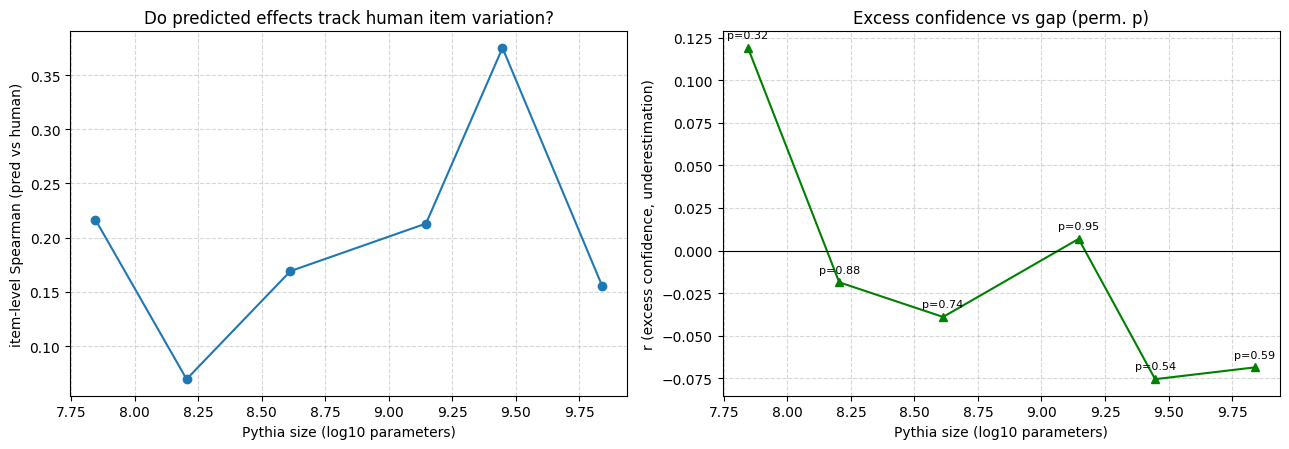

In [ ]:
# computing item-level spearman for each model
spearman_by_model = []
for m in models:
    d = e0[e0.model == m]
    rho = stats.spearmanr(d.pred_surprisal_ms, d.human)[0] if len(d) > 3 else np.nan
    spearman_by_model.append((x_vals[m], rho))
    
sp_df = pd.DataFrame(spearman_by_model, columns=["x", "rho"])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

# left panel: does the model rank items correctly?
ax[0].plot(sp_df.x, sp_df.rho, marker="o")
ax[0].set_ylabel("item-level Spearman (pred vs human)")
ax[0].set_title("Do predicted effects track human item variation?")
ax[0].set_xlabel("Pythia size (log10 parameters)")
ax[0].grid(True, ls="--", alpha=.5)

# right panel: excess confidence correlation and p-values
exc_sorted = exc.sort_values("log10_params")
ax[1].plot(exc_sorted.log10_params, exc_sorted.r, marker="^", color="g")
for _, row in exc_sorted.iterrows():
    ax[1].annotate(f"p={row.p_perm:.2f}", (row.log10_params, row.r), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
ax[1].axhline(0, c="k", lw=.8)
ax[1].set_ylabel("r (excess confidence, underestimation)")
ax[1].set_title("Excess confidence vs gap (perm. p)")
ax[1].set_xlabel("Pythia size (log10 parameters)")
ax[1].grid(True, ls="--", alpha=.5)

plt.tight_layout()
plt.savefig(f"{res_dir}/fig2_mechanism.png", dpi=300)
plt.show()

#### Figure : Predicted vs human effect per construction type.

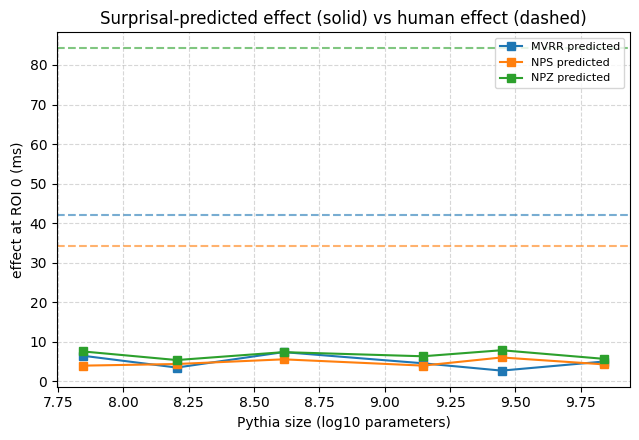

In [ ]:
# comparing what surprisal predicted vs what humans actually did broken down by construction type
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for i, c in enumerate(sorted(e0.CONSTRUCTION.unique())):
    d = e0[e0.CONSTRUCTION == c].groupby("model")[["pred_surprisal_ms", "human"]].mean().loc[models]
    ax.plot(X, d.pred_surprisal_ms, marker="s", color=f"C{i}", label=f"{c} predicted")
    ax.axhline(d.human.mean(), ls="--", color=f"C{i}", alpha=.6)
    
ax.set_xlabel("Pythia size (log10 parameters)")
ax.set_ylabel("effect at ROI 0 (ms)")
ax.set_title("Surprisal-predicted effect (solid) vs human effect (dashed)")
ax.legend(fontsize=8)
ax.grid(True, ls="--", alpha=.5)

plt.tight_layout()
plt.savefig(f"{res_dir}/fig4_pred_vs_human.png", dpi=300)
plt.show()

## Data Visualization
Plotting the scaling curves.

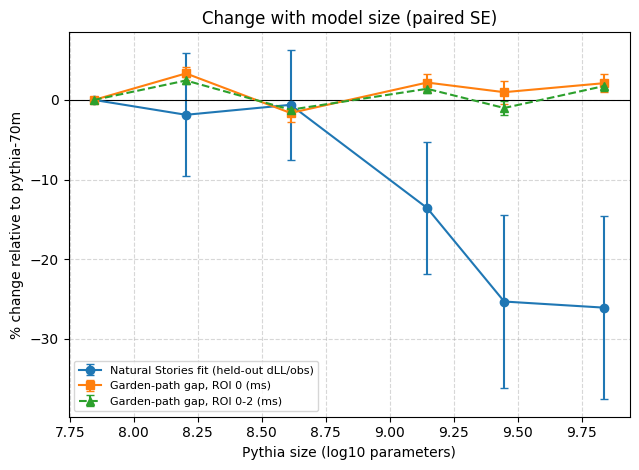

In [ ]:
ns = pd.read_csv(f"{res_dir}/natural_stories_heldout_summary.csv").sort_values("params")
ns_story = pd.read_csv(f"{res_dir}/natural_stories_per_story.csv")
eff = pd.read_csv(f"{res_dir}/gp_item_effects_all_models.csv")

models = ns.model.tolist()
base = models[0]
x_vals = dict(zip(ns.model, ns.log10_params))

# converting the calculated raw metrics into a percentage change relative to the smallest model
def rel_curve(per_unit, unit_col, val_col):
    P = per_unit.pivot_table(index=unit_col, columns="model", values=val_col)[models].dropna()
    ref = P[base].mean()
    out = []
    for m in models:
        d = P[m] - P[base]
        out.append((m, d.mean() / abs(ref) * 100, d.std(ddof=1) / np.sqrt(len(d)) / abs(ref) * 100 if m != base else 0.0))
    return pd.DataFrame(out, columns=["model", "rel", "se"]).assign(x=lambda d: d.model.map(x_vals))

ns_rel = rel_curve(ns_story, "story", "dLL_per_obs")

curves = {}
for roi in ("0", "0-2"):
    e = eff[eff.ROI.astype(str) == roi].copy()
    e["gap"] = e.human - e.pred_surprisal_ms
    e["unit"] = e.CONSTRUCTION + "_" + e.item.astype(str)
    curves[roi] = rel_curve(e, "unit", "gap")

#generating plots
fig, ax = plt.subplots(figsize=(6.5, 4.8))

# normalized comparison
ax.errorbar(ns_rel.x, ns_rel.rel, yerr=ns_rel.se, marker="o", capsize=3, label="Natural Stories fit (held-out dLL/obs)")
ax.errorbar(curves["0"].x, curves["0"].rel, yerr=curves["0"].se, marker="s", capsize=3, label="Garden-path gap, ROI 0 (ms)")
ax.errorbar(curves["0-2"].x, curves["0-2"].rel, yerr=curves["0-2"].se, marker="^", capsize=3, ls="--", label="Garden-path gap, ROI 0-2 (ms)")
ax.axhline(0, c="k", lw=.8)
ax.set_xlabel("Pythia size (log10 parameters)")
ax.set_ylabel(f"% change relative to {base.replace('-deduped','')}")
ax.set_title("Change with model size ")
ax.legend(fontsize=8)
ax.grid(True, ls="--", alpha=.5)

plt.tight_layout()
plt.savefig(f"{res_dir}/fig3_ns_vs_gp_comparison.png", dpi=300)
plt.show()